# 1. LinearRegression(선형 회귀)
### 공부 시간에 따른 시험 점수

ex) 공부시간과 시험점수의 관계
Independent variable 독립 변수 (원인) = 입력 변수, feature - 공부 시간
Dependent variable 종속변수 (결과) = 출력 변수, target, label - 시험 점수


전체 데이터를 표현하는 최적의 선 찾기
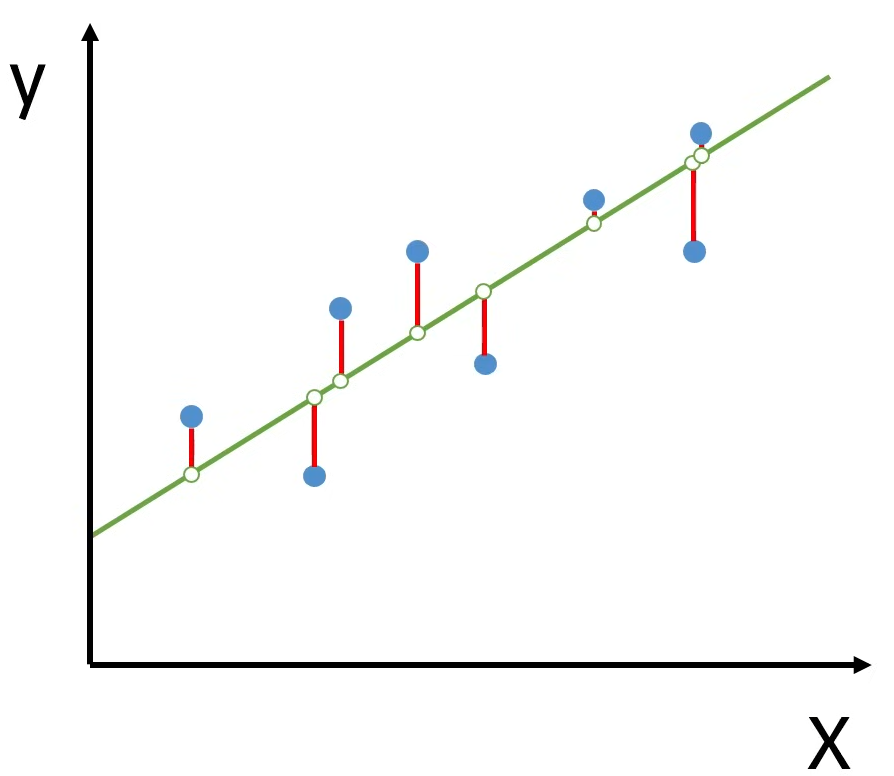
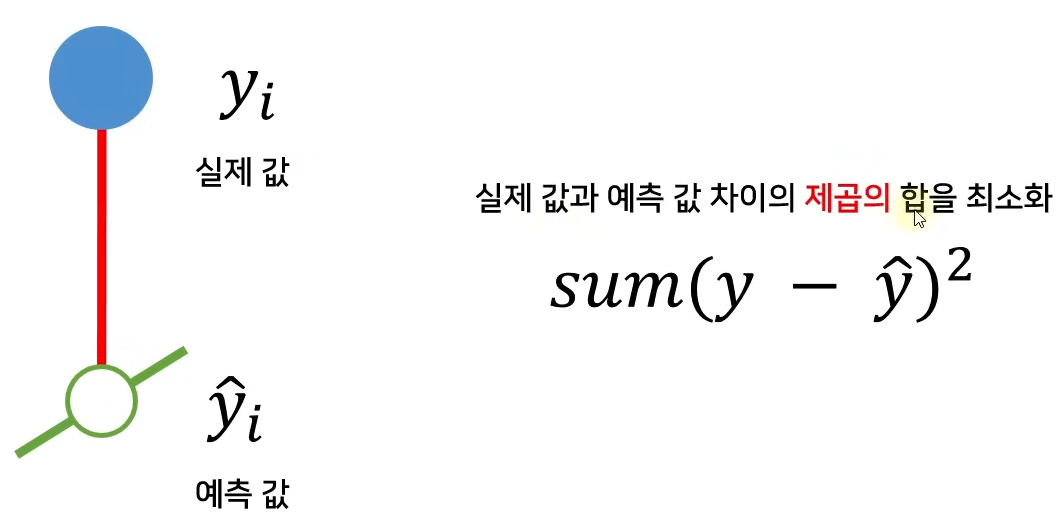
+-의 값을 수치를 제곱해줌 -> 모두 양수가 됨
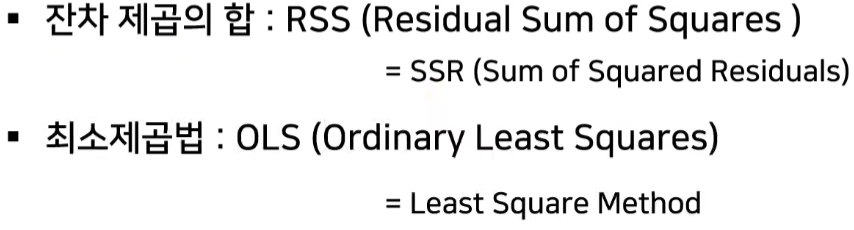
최소제곱법은 이산값(노이즈)에 취약하다

y = mx + b
m: 기울기, b: y절편

<!--업데이트 방법-->
!pip install scikit-learn --user --upgrade

In [1]:
import matplotlib.pyplot as plt #데이터 시각화 라이브러리
import pandas as pd #데이터 가공 라이브러리

In [2]:
dataSet = pd.read_csv('LinearRegressionData.csv') #데이터 셋 불러오기

In [3]:
dataSet.head(5) # 상위 5개 데이터

,hour,score
0,0.5,10
1,1.2,8
2,1.8,14
3,2.4,26
4,2.6,22


In [4]:
X = dataSet.iloc[:, :-1].values # 독립변수 (처틈부터 마지막 컬럼 직전까지의 데이터)
y = dataSet.iloc[:, -1].values # 종속변수 (마지막 컬럼 데이터)
print(X,y)

[[ 0.5]
 [ 1.2]
 [ 1.8]
 [ 2.4]
 [ 2.6]
 [ 3.2]
 [ 3.9]
 [ 4.4]
 [ 4.5]
 [ 5. ]
 [ 5.3]
 [ 5.8]
 [ 6. ]
 [ 6.1]
 [ 6.2]
 [ 6.9]
 [ 7.2]
 [ 8.4]
 [ 8.6]
 [10. ]] [ 10   8  14  26  22  30  42  48  38  58  60  72  62  68  72  58  76  86
  90 100]


In [17]:
# 선형 회귀 모델 만들기
from sklearn.linear_model import LinearRegression
reg = LinearRegression() # 객체 생성
reg.fit(X,y) # reg를 fit 함수로 학습, 모델 생성

LinearRegression()

In [6]:
y_pred = reg.predict(X) # X에 대한 Score예측 값
print(y_pred)

[  5.00336377  12.31395163  18.58016979  24.84638795  26.93512734
  33.20134551  40.51193337  45.73378184  46.77815153  52.
  55.13310908  60.35495755  62.44369694  63.48806663  64.53243633
  71.84302419  74.97613327  87.5085696   89.59730899 104.2184847 ]


Text(0, 0.5, 'score')

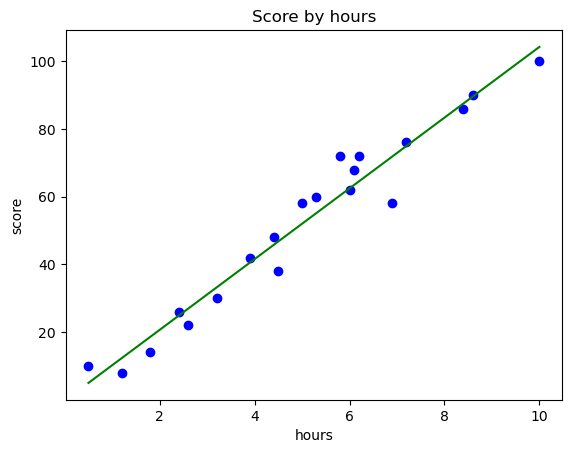

In [10]:
plt.scatter(X,y, color='blue') #산점도 그래프
plt.plot(X, y_pred, color='green') # 선 그래프, LinearRegression 모델을 통해 산점도 그래프를 잘 표현하는 최적의 선을 그려줌
plt.title('Score by hours') # 제목
plt.xlabel('hours') # X축 제목
plt.ylabel('score') # Y축 제목

In [18]:
print('9시간 공부했을 때 예상 점수: ', reg.predict([[9]])) #데이터 자체가 2차원배열, 입력할 때 2차원 형식으로, [[9], [8], [7]]

9시간 공부했을 때 예상 점수:  [93.77478776]


In [15]:
reg.coef_ # 기울기(m)

array([10.44369694])

In [16]:
reg.intercept_ # y 절편 (b)

-0.21848470286721522

단순 선형 회귀(Simple Linear Regression) 모델
Target y, Feature x, Parameter m,b
y = mx +b => y= 10.4436 X -0.2184

### 데이터 세트 분리
#### 훈련 세트, 테스트 세트

In [19]:
import matplotlib.pyplot as plt #데이터 시각화 라이브러리
import pandas as pd #데이터 가공 라이브러리

In [25]:
dataSet = pd.read_csv('LinearRegressionData.csv')
dataSet

,hour,score
0,0.5,10
1,1.2,8
2,1.8,14
3,2.4,26
4,2.6,22
5,3.2,30
6,3.9,42
7,4.4,48
8,4.5,38
9,5.0,58


In [21]:
# 독립, 종속 변수 분리
X = dataSet.iloc[:,:-1].values
y = dataSet.iloc[:, -1].values

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) #test_size=테스트 세트를 20%, 훈련 80: 테스트 20

In [23]:
X, len(X) #전체 데이터 X, 개수

(array([[ 0.5],
        [ 1.2],
        [ 1.8],
        [ 2.4],
        [ 2.6],
        [ 3.2],
        [ 3.9],
        [ 4.4],
        [ 4.5],
        [ 5. ],
        [ 5.3],
        [ 5.8],
        [ 6. ],
        [ 6.1],
        [ 6.2],
        [ 6.9],
        [ 7.2],
        [ 8.4],
        [ 8.6],
        [10. ]]),
 20)

In [24]:
X_train, len(X_train) # 훈련 세트 X, 개수

(array([[5.3],
        [8.4],
        [3.9],
        [6.1],
        [2.6],
        [1.8],
        [3.2],
        [6.2],
        [5. ],
        [4.4],
        [7.2],
        [5.8],
        [2.4],
        [0.5],
        [6.9],
        [6. ]]),
 16)

In [27]:
X_test, len(X_test) # 테스트 세트 X, 개수

(array([[ 8.6],
        [ 1.2],
        [10. ],
        [ 4.5]]),
 4)

In [28]:
y, len(y) #전체 데이터 y

(array([ 10,   8,  14,  26,  22,  30,  42,  48,  38,  58,  60,  72,  62,
         68,  72,  58,  76,  86,  90, 100], dtype=int64),
 20)

In [29]:
y_train, len(y_train) #훈련 세트 y

(array([60, 86, 42, 68, 22, 14, 30, 72, 58, 48, 76, 72, 26, 10, 58, 62],
       dtype=int64),
 16)

In [30]:
y_test, len(y_test) #테스트 세트 y

(array([ 90,   8, 100,  38], dtype=int64), 4)

### 분리된 데이터를 통한 모델링

In [33]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [34]:
reg.fit(X_train, y_train)

LinearRegression()

### 데이터 시각화(훈련 세트)

Text(0, 0.5, 'score')

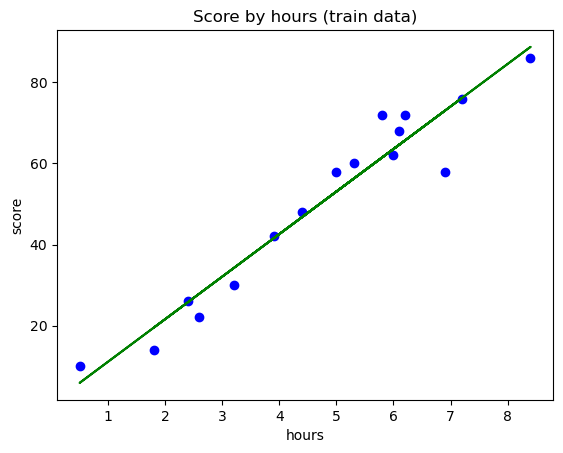

In [36]:
plt.scatter(X_train, y_train, color='blue') #산점도 그래프
plt.plot(X_train, reg.predict(X_train), color='green') # 선 그래프, LinearRegression 모델을 통해 산점도 그래프를 잘 표현하는 최적의 선을 그려줌
plt.title('Score by hours (train data)') # 제목
plt.xlabel('hours') # X축 제목
plt.ylabel('score') # Y축 제목

### 데이터 시각화(테스트 세트)

Text(0, 0.5, 'score')

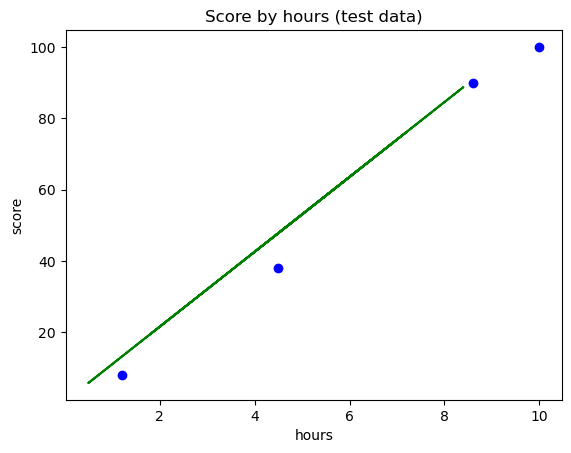

In [39]:
plt.scatter(X_test, y_test, color='blue') #산점도 그래프

#모델을 만들때 훈련 세트로 만들어서 선그래프는 그냥 훈련 세트 그대로
plt.plot(X_train, reg.predict(X_train), color='green') # 선 그래프, LinearRegression 모델을 통해 산점도 그래프를 잘 표현하는 최적의 선을 그려줌

plt.title('Score by hours (test data)') # 제목
plt.xlabel('hours') # X축 제목
plt.ylabel('score') # Y축 제목

In [40]:
reg.coef_ # 기울가m

array([10.49161294])

In [42]:
reg.intercept_ # y절편 b

0.6115562905169796

### 모델 평가

In [44]:
reg.score(X_test, y_test) #테스트 세트를 통한 모델 평가 0~1

0.9727616474310156

In [46]:
reg.score(X_train, y_train) #훈련 세트를 통한 모델 평가 0~1

0.9356663661221668

## 경사 하강법(Gradient Descent)
#### 학습률(Learning rate) = 0.001, 0.003, 0.01, 0.03, 0.1, 0.3
#### 에포크(Epoch): 최적의 parameter를 찾기 위해서 훈련세트의 모든 데이터를 한 번씩 사용하는 과정
#### 전체 데이터를 모두 사용하여 기울기를 계산 => 컴퓨터 자원을 많이 필요로 함, 경우에 따라서는 한 번에 많은 데이터를 읽지 못할 수도 있다.

### 확률적 경사 하강법(Stochastic Gradient Descent)
#### 매 단계마다 딱 하나의 데이터만 무작위로 선택하고 그 데이터에 대해서만 기울기를 계산함

#####  경사 하강법 시각화 자료: https://alykhantejani.github.io/images/gradient_descent_line_graph.gif
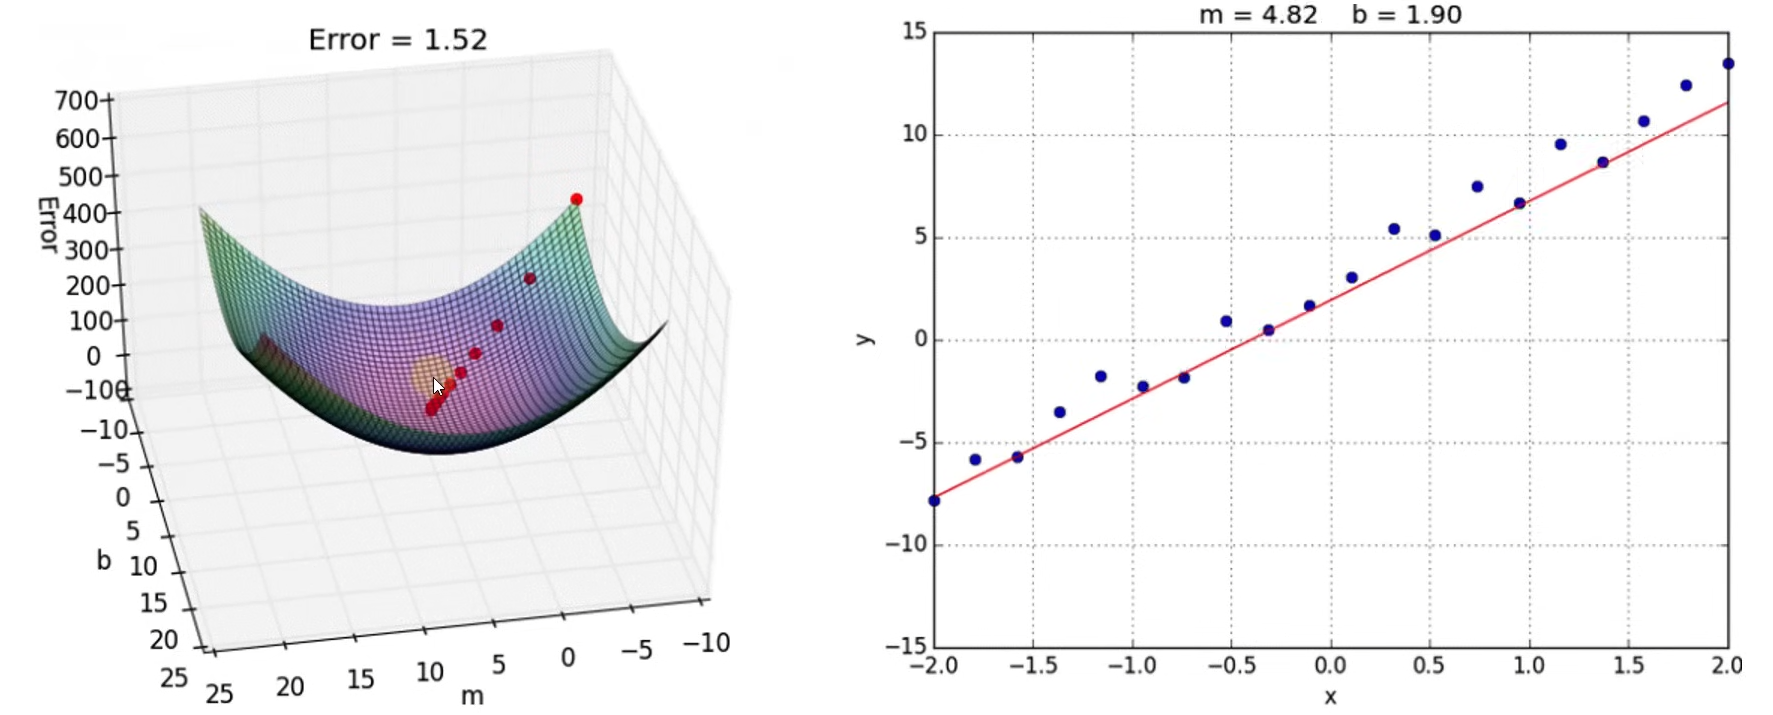

## 경사 하강법(Gradient Descent)

In [48]:
from sklearn.linear_model import SGDRegressor # SGD: Stochastic Gradeint Descent 확률적 경사 하강법
sr = SGDRegressor()
sr.fit(X_train, y_train)
sr

SGDRegressor()

Text(0, 0.5, 'score')

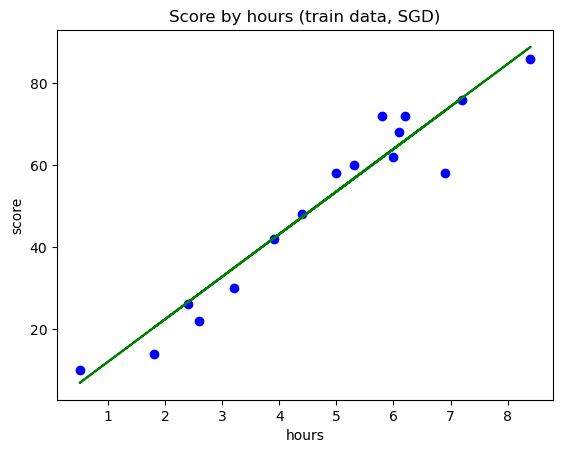

In [49]:
plt.scatter(X_train, y_train, color='blue') #산점도 그래프
plt.plot(X_train, sr.predict(X_train), color='green') # 선 그래프, LinearRegression 모델을 통해 산점도 그래프를 잘 표현하는 최적의 선을 그려줌
plt.title('Score by hours (train data, SGD)') # 제목
plt.xlabel('hours') # X축 제목
plt.ylabel('score') # Y축 제목

In [51]:
#훈련데이터의 평가 점수와 비교
reg.coef_, reg.intercept_

(array([10.49161294]), 0.6115562905169796)

In [52]:
sr.coef_, sr.intercept_

(array([10.38547186]), array([1.63530157]))

In [54]:
sr.score(X_test,y_test) #테스트 세트를 통한 모델 평가

0.9690776144148247

In [55]:
sr.score(X_train,y_train) #훈련 세트를 통한 모델 평가

0.9350499072869313

좋은 모델은 훈련 세트의 모델 평가가 더 높고 테스트 세트의 모델 평가가 조금 더 낮은데 데이터 수가 적기 때문에 반대로 나오게 됨

In [66]:
# 학습률 정의
# max_iter(훈련 세트 반복 횟수 Epoch), eta0(학습률 Learning rate)
# eta0 = 0.001 == eta0 = 1e-3, 지수 표기법으로 표기 가능
# max_iter와 eta0의 값을 잘 조율하지 않으면 에러메시지가 생긴다. (더 나은 모델 만들기 위해서 값을 조절해라 ~)
sr = SGDRegressor(max_iter=200, eta0=1e-4, random_state=0, verbose=1) 
sr.fit(X_train, y_train)

-- Epoch 1
Norm: 0.27, NNZs: 1, Bias: 0.048869, T: 16, Avg. loss: 1484.241876
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.47, NNZs: 1, Bias: 0.083896, T: 32, Avg. loss: 1419.741822
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.64, NNZs: 1, Bias: 0.114272, T: 48, Avg. loss: 1367.983092
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.79, NNZs: 1, Bias: 0.141552, T: 64, Avg. loss: 1322.870279
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.94, NNZs: 1, Bias: 0.166772, T: 80, Avg. loss: 1282.550224
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.07, NNZs: 1, Bias: 0.190476, T: 96, Avg. loss: 1245.587071
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1.20, NNZs: 1, Bias: 0.212877, T: 112, Avg. loss: 1211.227118
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 1.32, NNZs: 1, Bias: 0.234194, T: 128, Avg. loss: 1179.037565
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 1.43, NNZs: 1, Bias: 0.254556, T: 144, Avg. loss: 1148.814106
Total training 

C:\Users\pkr90\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDRegressor(eta0=0.0001, max_iter=200, random_state=0, verbose=1)

loss(손실)값: 점차 낮아짐

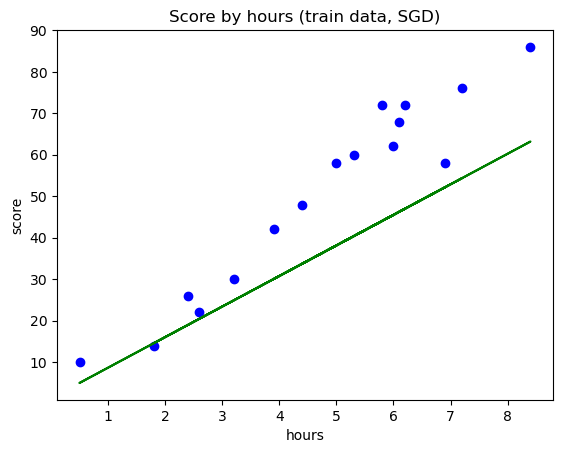

In [64]:
plt.scatter(X_train, y_train, color='blue') #산점도 그래프
plt.plot(X_train, sr.predict(X_train), color='green') # 선 그래프, LinearRegression 모델을 통해 산점도 그래프를 잘 표현하는 최적의 선을 그려줌
plt.title('Score by hours (train data, SGD)') # 제목
plt.xlabel('hours') # X축 제목
plt.ylabel('score') # Y축 제목
plt.show()